In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import stac

In [2]:
import scipy
import scikit_posthocs as sp
import matplotlib.pyplot as plt

In [3]:
df_pivot_tss = pd.read_csv("TSS Comparison.csv", index_col=0)
df_pivot_clr = pd.read_csv("CLR Comparison.csv", index_col=0)
df_pivot_logtss = pd.read_csv("logTSS Comparison.csv", index_col=0)
df_pivot_pa = pd.read_csv("PA Comparison.csv", index_col=0)

## Multiple Comparisons Classiffiers

In [10]:
colors = ranks.copy()
colors["Boosting"] = "blue"
colors["LogisticRegression"] = "grey"
colors["RandomForest"] = "red"
colors["SVM"] = "skyblue"
colors["KNN"] = "yellow"

In [11]:
statistic, p_value, ranking, rank_cmp  = stac.friedman_test(*np.transpose(np.asarray(df_pivot_tss)))
ranks = {key: rank_cmp[i] for i, key in enumerate(list(df_pivot_tss.columns))} 
ranking2 = {key: ranking[i] for i, key in enumerate(list(df_pivot_tss.columns))} 
comparisons, z_values, p_values, adj_p_values = stac.finner_multitest(ranks)
adj_p_values = np.asarray(adj_p_values)
for comparison, p in zip(comparisons, adj_p_values):
    print(f"{comparison}: {p:.6f}")

KNN vs RandomForest: 0.000004
RandomForest vs SVM: 0.000693
Boosting vs KNN: 0.001147
LogisticRegression vs RandomForest: 0.009703
Boosting vs SVM: 0.041405
KNN vs LogisticRegression: 0.046623
Boosting vs RandomForest: 0.184879
Boosting vs LogisticRegression: 0.202830
KNN vs SVM: 0.223951
LogisticRegression vs SVM: 0.355611


In [12]:
models = ["KNN", "RandomForest", "SVM", "LogisticRegression", "Boosting"]

p_values = {
    ("KNN", "RandomForest"): 0.000004,
    ("RandomForest", "SVM"): 0.000693,
    ("Boosting", "KNN"): 0.001147,
    ("LogisticRegression", "RandomForest"): 0.009703,
    ("Boosting", "SVM"): 0.041405,
    ("KNN", "LogisticRegression"): 0.046623,
    ("Boosting", "RandomForest"): 0.184879,
    ("Boosting", "LogisticRegression"): 0.202830,
    ("KNN", "SVM"): 0.223951,
    ("LogisticRegression", "SVM"): 0.355611,
}

p_matrix = pd.DataFrame(np.nan, index=models, columns=models)

for (model1, model2), p_val in p_values.items():
    p_matrix.loc[model1, model2] = p_val
    p_matrix.loc[model2, model1] = p_val  # Simetría

np.fill_diagonal(p_matrix.values, 0)

In [13]:
statistic, p_value, ranking, rank_cmp  = stac.friedman_test(*np.transpose(np.asarray(df_pivot_clr)))
ranks = {key: rank_cmp[i] for i, key in enumerate(list(df_pivot_clr.columns))} 

comparisons, z_values, p_values, adj_p_values = stac.finner_multitest(ranks)
adj_p_values = np.asarray(adj_p_values)
for comparison, p_value in zip(comparisons, adj_p_values):
    print(f"{comparison}: {p_value:.6f}")

KNN vs LogisticRegression: 0.000001
LogisticRegression vs RandomForest: 0.000057
KNN vs SVM: 0.000462
Boosting vs KNN: 0.006687
RandomForest vs SVM: 0.011136
Boosting vs LogisticRegression: 0.025393
Boosting vs RandomForest: 0.070163
LogisticRegression vs SVM: 0.130658
KNN vs RandomForest: 0.325808
Boosting vs SVM: 0.418923


In [14]:
models = ["KNN", "RandomForest", "SVM", "LogisticRegression", "Boosting"]

p_values = {
    ("KNN", "RandomForest"): 0.325808,
    ("RandomForest", "SVM"): 0.011136,
    ("Boosting", "KNN"): 0.006687,
    ("LogisticRegression", "RandomForest"): 0.000057,
    ("Boosting", "SVM"): 0.418923,
    ("KNN", "LogisticRegression"): 0.000001,
    ("Boosting", "LogisticRegression"): 0.025393,
    ("Boosting", "RandomForest"): 0.070163,
    ("KNN", "SVM"): 0.000462,
    ("LogisticRegression", "SVM"): 0.130658,
}

p_matrix = pd.DataFrame(np.nan, index=models, columns=models)

for (model1, model2), p_val in p_values.items():
    p_matrix.loc[model1, model2] = p_val
    p_matrix.loc[model2, model1] = p_val  # Simetría
np.fill_diagonal(p_matrix.values, 0)

print(p_matrix)


                         KNN  RandomForest       SVM  LogisticRegression  \
KNN                 0.000000      0.325808  0.000462            0.000001   
RandomForest        0.325808      0.000000  0.011136            0.000057   
SVM                 0.000462      0.011136  0.000000            0.130658   
LogisticRegression  0.000001      0.000057  0.130658            0.000000   
Boosting            0.006687      0.070163  0.418923            0.025393   

                    Boosting  
KNN                 0.006687  
RandomForest        0.070163  
SVM                 0.418923  
LogisticRegression  0.025393  
Boosting            0.000000  


In [15]:
statistic, p_value, ranking, rank_cmp  = stac.friedman_test(*np.transpose(np.asarray(df_pivot_logtss)))
ranks = {key: rank_cmp[i] for i, key in enumerate(list(df_pivot_logtss.columns))} 

comparisons, z_values, p_values, adj_p_values = stac.finner_multitest(ranks)
adj_p_values = np.asarray(adj_p_values)
for comparison, p_value in zip(comparisons, adj_p_values):
    print(f"{comparison}: {p_value:.6f}")

KNN vs LogisticRegression: 0.000007
LogisticRegression vs RandomForest: 0.000266
KNN vs SVM: 0.000733
Boosting vs KNN: 0.004551
RandomForest vs SVM: 0.011136
Boosting vs RandomForest: 0.046623
Boosting vs LogisticRegression: 0.091092
LogisticRegression vs SVM: 0.248161
KNN vs RandomForest: 0.386320
Boosting vs SVM: 0.563703


In [16]:
models = ["KNN", "RandomForest", "SVM", "LogisticRegression", "Boosting"]

# Define the p-values with the new values
p_values = {
    ("KNN", "LogisticRegression"): 0.000007,
    ("LogisticRegression", "RandomForest"): 0.000266,
    ("KNN", "SVM"): 0.000733,
    ("Boosting", "KNN"): 0.004551,
    ("RandomForest", "SVM"): 0.011136,
    ("Boosting", "RandomForest"): 0.046623,
    ("Boosting", "LogisticRegression"): 0.091092,
    ("LogisticRegression", "SVM"): 0.248161,
    ("KNN", "RandomForest"): 0.386320,
    ("Boosting", "SVM"): 0.563703
}

# Create an empty matrix filled with NaN
p_matrix = pd.DataFrame(np.nan, index=models, columns=models)

# Fill the matrix with p-values
for (model1, model2), p_val in p_values.items():
    p_matrix.loc[model1, model2] = p_val
    p_matrix.loc[model2, model1] = p_val  # Symmetry

# Set diagonal to 0
np.fill_diagonal(p_matrix.values, 0)

# Display the matrix
print(p_matrix)

                         KNN  RandomForest       SVM  LogisticRegression  \
KNN                 0.000000      0.386320  0.000733            0.000007   
RandomForest        0.386320      0.000000  0.011136            0.000266   
SVM                 0.000733      0.011136  0.000000            0.248161   
LogisticRegression  0.000007      0.000266  0.248161            0.000000   
Boosting            0.004551      0.046623  0.563703            0.091092   

                    Boosting  
KNN                 0.004551  
RandomForest        0.046623  
SVM                 0.563703  
LogisticRegression  0.091092  
Boosting            0.000000  


In [17]:
statistic, p_value, ranking, rank_cmp  = stac.friedman_test(*np.transpose(np.asarray(df_pivot_pa)))
ranks = {key: rank_cmp[i] for i, key in enumerate(list(df_pivot_pa.columns))} 

comparisons, z_values, p_values, adj_p_values = stac.finner_multitest(ranks)
adj_p_values = np.asarray(adj_p_values)
for comparison, p_value in zip(comparisons, adj_p_values):
    print(f"{comparison}: {p_value:.6f}")

KNN vs LogisticRegression: 0.000067
KNN vs SVM: 0.001720
KNN vs RandomForest: 0.001772
Boosting vs LogisticRegression: 0.002029
Boosting vs SVM: 0.030393
Boosting vs RandomForest: 0.034625
Boosting vs KNN: 0.334738
LogisticRegression vs RandomForest: 0.358227
LogisticRegression vs SVM: 0.386320
RandomForest vs SVM: 0.908073


In [18]:
import pandas as pd
import numpy as np

# Define the models
models = ["KNN", "RandomForest", "SVM", "LogisticRegression", "Boosting"]

# Define the p-values with the new values
p_values = {
    ("KNN", "LogisticRegression"): 0.000067,
    ("KNN", "SVM"): 0.001720,
    ("KNN", "RandomForest"): 0.001772,
    ("Boosting", "LogisticRegression"): 0.002029,
    ("Boosting", "SVM"): 0.030393,
    ("Boosting", "RandomForest"): 0.034625,
    ("Boosting", "KNN"): 0.334738,
    ("LogisticRegression", "RandomForest"): 0.358227,
    ("LogisticRegression", "SVM"): 0.386320,
    ("RandomForest", "SVM"): 0.908073
}

# Create an empty matrix filled with NaN
p_matrix = pd.DataFrame(np.nan, index=models, columns=models)

# Fill the matrix with p-values
for (model1, model2), p_val in p_values.items():
    p_matrix.loc[model1, model2] = p_val
    p_matrix.loc[model2, model1] = p_val  # Symmetry

# Set diagonal to 0
np.fill_diagonal(p_matrix.values, 0)

# Display the matrix
print(p_matrix)

                         KNN  RandomForest       SVM  LogisticRegression  \
KNN                 0.000000      0.001772  0.001720            0.000067   
RandomForest        0.001772      0.000000  0.908073            0.358227   
SVM                 0.001720      0.908073  0.000000            0.386320   
LogisticRegression  0.000067      0.358227  0.386320            0.000000   
Boosting            0.334738      0.034625  0.030393            0.002029   

                    Boosting  
KNN                 0.334738  
RandomForest        0.034625  
SVM                 0.030393  
LogisticRegression  0.002029  
Boosting            0.000000  


                         KNN  RandomForest       SVM  LogisticRegression  \
KNN                 0.000000      0.000004  0.223951            0.046623   
RandomForest        0.000004      0.000000  0.000693            0.009703   
SVM                 0.223951      0.000693  0.000000            0.355611   
LogisticRegression  0.046623      0.009703  0.355611            0.000000   
Boosting            0.001147      0.184879  0.041405            0.202830   

                    Boosting  
KNN                 0.001147  
RandomForest        0.184879  
SVM                 0.041405  
LogisticRegression  0.202830  
Boosting            0.000000  
                         KNN  RandomForest       SVM  LogisticRegression  \
KNN                 0.000000      0.325808  0.000462            0.000001   
RandomForest        0.325808      0.000000  0.011136            0.000057   
SVM                 0.000462      0.011136  0.000000            0.130658   
LogisticRegression  0.000001      0.000057  0.130658 

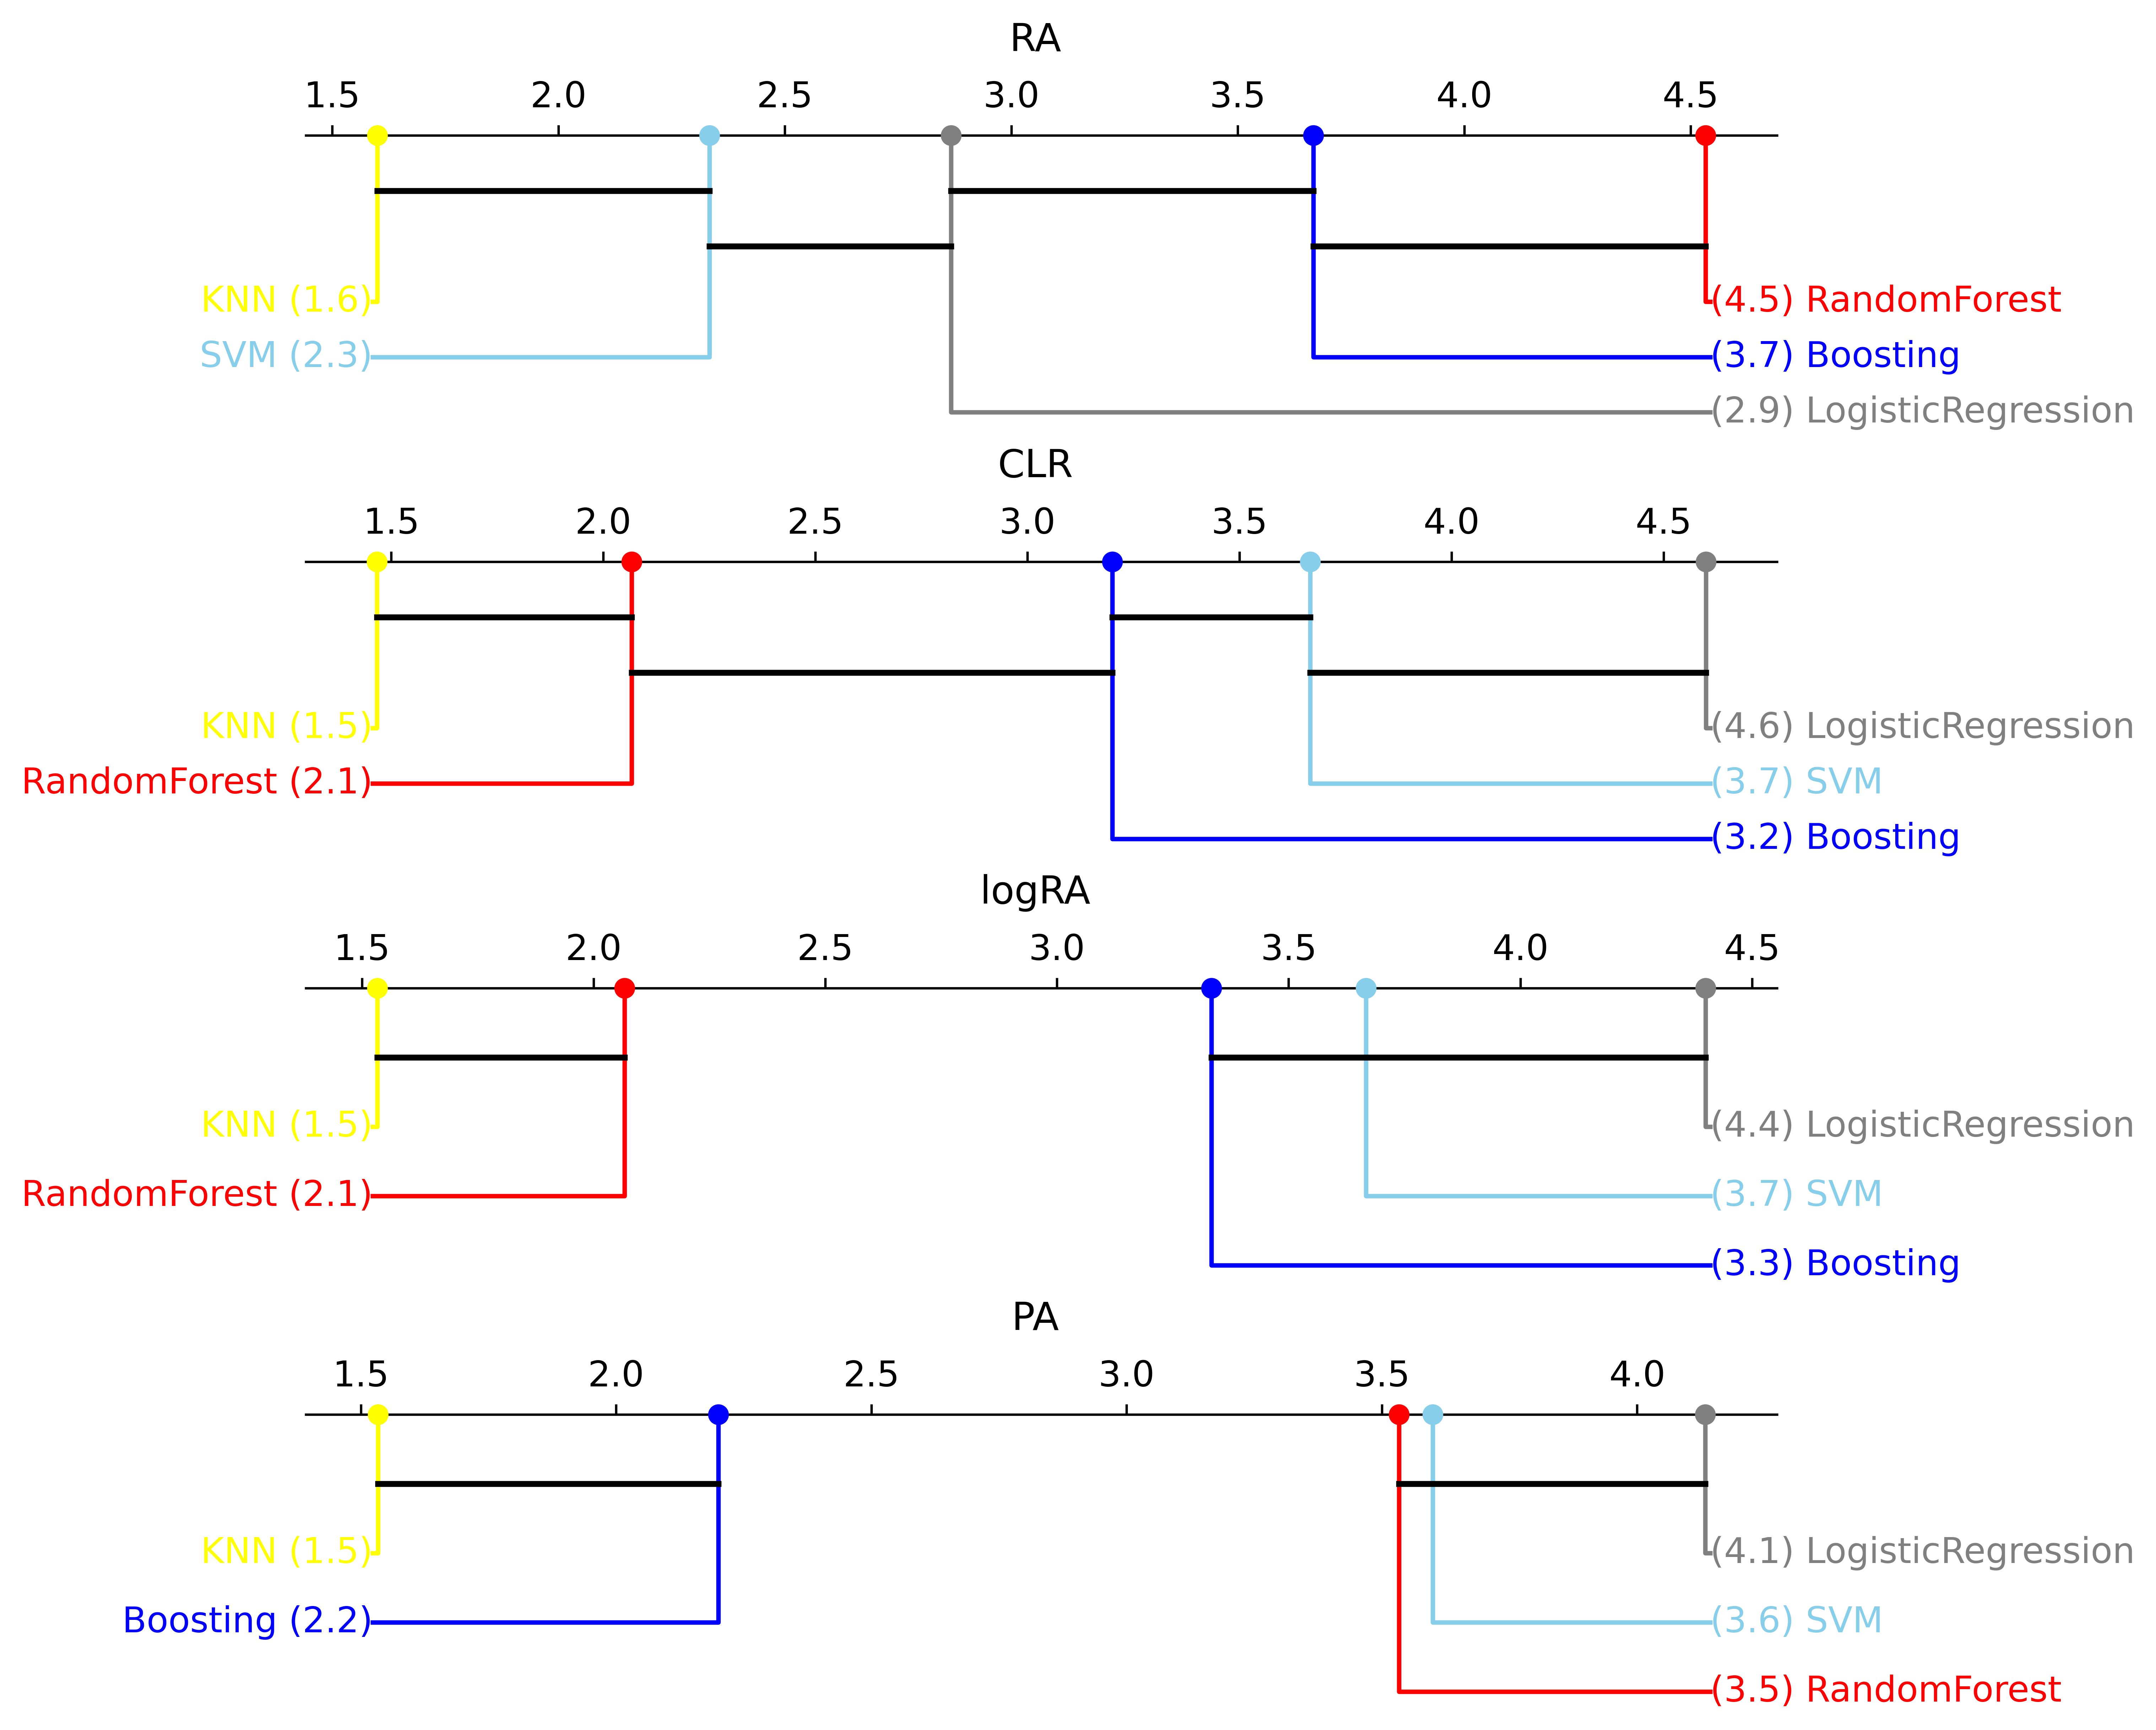

In [19]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import scikit_posthocs as sp
import stac  # adjust if needed

# Set global font and style for publication
plt.rcParams.update({
    "font.size": 12,
    "figure.dpi": 600,
    "savefig.dpi": 600,
    "figure.figsize": (12, 8)
})

# Shared model list and color map
models = ["KNN", "RandomForest", "SVM", "LogisticRegression", "Boosting"]
colors = {
    "Boosting": "blue",
    "LogisticRegression": "grey",
    "RandomForest": "red",
    "SVM": "skyblue",
    "KNN": "yellow"
}

# Function to prepare and return rank and p-value matrix
def compute_diagram(df_pivot, p_values_dict):
    stat, p_val, ranking, rank_cmp = stac.friedman_test(*np.transpose(np.asarray(df_pivot)))
    ranks = {key: rank_cmp[i] for i, key in enumerate(list(df_pivot.columns))}
    ranking = {key: ranking[i] for i, key in enumerate(list(df_pivot.columns))}
    # Create p-value matrix
    p_matrix = pd.DataFrame(np.nan, index=models, columns=models)
    for (m1, m2), p in p_values_dict.items():
        p_matrix.loc[m1, m2] = p
        p_matrix.loc[m2, m1] = p
    np.fill_diagonal(p_matrix.values, 0)
    return ranking, p_matrix

# Define your datasets and p-values
datasets = [
    ("RA", df_pivot_tss, {
        ("KNN", "RandomForest"): 0.000004, ("RandomForest", "SVM"): 0.000693,
        ("Boosting", "KNN"): 0.001147, ("LogisticRegression", "RandomForest"): 0.009703,
        ("Boosting", "SVM"): 0.041405, ("KNN", "LogisticRegression"): 0.046623,
        ("Boosting", "RandomForest"): 0.184879, ("Boosting", "LogisticRegression"): 0.202830,
        ("KNN", "SVM"): 0.223951, ("LogisticRegression", "SVM"): 0.355611
    }),
    ("CLR", df_pivot_clr, {
        ("KNN", "RandomForest"): 0.325808, ("RandomForest", "SVM"): 0.011136,
        ("Boosting", "KNN"): 0.006687, ("LogisticRegression", "RandomForest"): 0.000057,
        ("Boosting", "SVM"): 0.418923, ("KNN", "LogisticRegression"): 0.000001,
        ("Boosting", "LogisticRegression"): 0.025393, ("Boosting", "RandomForest"): 0.070163,
        ("KNN", "SVM"): 0.000462, ("LogisticRegression", "SVM"): 0.130658
    }),
    ("logRA", df_pivot_logtss, {
        ("KNN", "LogisticRegression"): 0.000007, ("LogisticRegression", "RandomForest"): 0.000266,
        ("KNN", "SVM"): 0.000733, ("Boosting", "KNN"): 0.004551,
        ("RandomForest", "SVM"): 0.011136, ("Boosting", "RandomForest"): 0.046623,
        ("Boosting", "LogisticRegression"): 0.091092, ("LogisticRegression", "SVM"): 0.248161,
        ("KNN", "RandomForest"): 0.386320, ("Boosting", "SVM"): 0.563703
    }),
    ("PA", df_pivot_pa, {
        ("KNN", "LogisticRegression"): 0.000067, ("KNN", "SVM"): 0.001720,
        ("KNN", "RandomForest"): 0.001772, ("Boosting", "LogisticRegression"): 0.002029,
        ("Boosting", "SVM"): 0.030393, ("Boosting", "RandomForest"): 0.034625,
        ("Boosting", "KNN"): 0.334738, ("LogisticRegression", "RandomForest"): 0.358227,
        ("LogisticRegression", "SVM"): 0.386320, ("RandomForest", "SVM"): 0.908073
    })
]

# Create the full figure with subplots
fig, axs = plt.subplots(nrows=4, figsize=(10, 8), constrained_layout=True)

for idx, (name, df, p_dict) in enumerate(datasets):
    ranks, p_matrix = compute_diagram(df, p_dict)
    print(p_matrix)
    plt.sca(axs[idx])
    sp.critical_difference_diagram(ranks, p_matrix, color_palette=colors)
    axs[idx].set_title(f"{name} ", fontsize=13, pad=10)

plt.show()


## Feature Selections Multiple Comparison

In [24]:
all = pd.read_csv("CombinedFS.csv", index_col=0)
ready = all.loc[:,["RA", "CLR", "logRA", "PA"]]

In [25]:
statistic, p_value, ranking, rank_cmp  = stac.friedman_test(*np.transpose(np.asarray(ready)))
ranks = {key: rank_cmp[i] for i, key in enumerate(list(ready.columns))} 
rankings = {key: ranking[i] for i, key in enumerate(list(ready.columns))} 
comparisons, z_values, p_values, adj_p_values = stac.finner_multitest(ranks)
adj_p_values = np.asarray(adj_p_values)
for comparison, p_value in zip(comparisons, adj_p_values):
    print(f"{comparison}: {p_value}")

RA vs CLR: 0.0
RA vs logRA: 0.0
RA vs PA: 0.0
CLR vs PA: 2.2648549702353193e-14
CLR vs logRA: 6.632472349110685e-13
logRA vs PA: 0.6350058912972965


In [27]:
algorithm_colors = {
    "RA": "#2a78b4",         # Azul
    "CLR": "#f0c042",          # Naranja
    "logRA": "#8c8c8c",         # Gris
    "PA": "#c85c57",           # Rojo
}

In [26]:
# Define the normalization methods
methods = ["RA", "CLR", "logRA", "PA"]

# Define the p-values between methods
p_values = {
    ("RA", "CLR"): 0.0000000000000000000000000000000000000000000000000000000001,
    ("RA", "logRA"): 0.0000000000000000000000000000000000000000000000000000000001,
    ("RA", "PA"): 0.0000000000000000000000000000000000000000000000000000000001,
    ("CLR", "PA"): 0.000000000000022648549702353193,
    ("CLR", "logRA"): 0.0000000000006632472349110685,
    ("logRA", "PA"): 0.6350058912972965
}

# Create an empty matrix filled with NaN
p_matrix = pd.DataFrame(np.nan, index=methods, columns=methods)

# Fill the matrix with p-values (symmetric)
for (method1, method2), p_val in p_values.items():
    p_matrix.loc[method1, method2] = p_val
    p_matrix.loc[method2, method1] = p_val  # Ensure symmetry

# Set diagonal to 0
np.fill_diagonal(p_matrix.values, 0)

# Display the matrix
print(p_matrix)

                 RA           CLR         logRA            PA
RA     0.000000e+00  1.000000e-58  1.000000e-58  1.000000e-58
CLR    1.000000e-58  0.000000e+00  6.632472e-13  2.264855e-14
logRA  1.000000e-58  6.632472e-13  0.000000e+00  6.350059e-01
PA     1.000000e-58  2.264855e-14  6.350059e-01  0.000000e+00


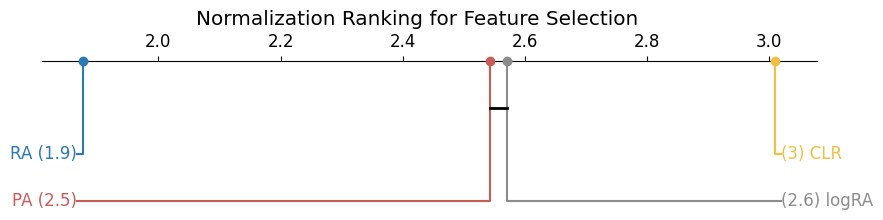

In [28]:
plt.figure(figsize=(10, 2), dpi=100)

plt.suptitle('Normalization Ranking for Feature Selection', y=1.1)

ax = sp.critical_difference_diagram(rankings, p_matrix, color_palette=algorithm_colors)

plt.plot()

In [20]:
clrs = pd.read_csv("NestedCLRFeatureSelectionFINAL.csv", index_col=0)
lr_df = clrs[clrs['Model'] == 'LogisticRegression']

# Pivot the table to get datasets as rows and FS methods as columns
auc_pivot = lr_df.pivot(index='Dataset', columns='FS_Method', values='AUC')

In [21]:
statistic, p_value, ranking, rank_cmp  = stac.friedman_test(*np.transpose(np.asarray(auc_pivot)))
ranks = {key: rank_cmp[i] for i, key in enumerate(list(auc_pivot.columns))} 
rankings = {key: ranking[i] for i, key in enumerate(list(auc_pivot.columns))} 
comparisons, z_values, p_values, adj_p_values = stac.finner_multitest(ranks)
adj_p_values = np.asarray(adj_p_values)
for comparison, p_value in zip(comparisons, adj_p_values):
    print(f"{comparison}: {p_value:.6f}")

VAE vs mRMR100: 0.000035
MIFS50 vs mRMR100: 0.000217
VAE vs mRMR50: 0.000902
LASSO vs VAE: 0.001290
Relief50 vs mRMR100: 0.002882
MIFS50 vs mRMR50: 0.003559
LASSO vs MIFS50: 0.005405
MIFS100 vs mRMR100: 0.005405
Relief100 vs mRMR100: 0.005405
RF50 vs mRMR100: 0.009349
AE50 vs mRMR100: 0.011995
AE100 vs VAE: 0.018095
Relief50 vs mRMR50: 0.026878
RF100 vs mRMR100: 0.033859
LASSO vs Relief50: 0.036694
MIFS100 vs mRMR50: 0.045980
Relief100 vs mRMR50: 0.045980
AE100 vs MIFS50: 0.054173
LASSO vs MIFS100: 0.058872
LASSO vs Relief100: 0.058872
RF100 vs VAE: 0.061048
RF50 vs mRMR50: 0.066529
AE50 vs mRMR50: 0.082206
LASSO vs RF50: 0.089293
AE100 vs mRMR100: 0.096930
AE50 vs LASSO: 0.105140
AE50 vs VAE: 0.127635
RF50 vs VAE: 0.153622
MIFS50 vs RF100: 0.153622
RF100 vs mRMR50: 0.160307
AE100 vs Relief50: 0.210641
LASSO vs RF100: 0.210641
MIFS100 vs VAE: 0.219382
Relief100 vs VAE: 0.219382
AE50 vs MIFS50: 0.274110
AE100 vs MIFS100: 0.291822
AE100 vs Relief100: 0.291822
MIFS50 vs RF50: 0.303492
Rel

In [22]:
# Define the methods (now including RF50 and RF100)
methods = [
    "VAE", "mRMR100", "AE100", "mRMR50", "MIFS50", 
    "LASSO", "Relief50", "MIFS100", "Relief100", "AE50",
    "RF50", "RF100"
]

# Define the p-values with the new values
p_values = {
    ("VAE", "mRMR100"): 0.000035,
    ("MIFS50", "mRMR100"): 0.000217,
    ("VAE", "mRMR50"): 0.000902,
    ("LASSO", "VAE"): 0.001290,
    ("Relief50", "mRMR100"): 0.002882,
    ("MIFS50", "mRMR50"): 0.003559,
    ("LASSO", "MIFS50"): 0.005405,
    ("MIFS100", "mRMR100"): 0.005405,
    ("Relief100", "mRMR100"): 0.005405,
    ("RF50", "mRMR100"): 0.009349,
    ("AE50", "mRMR100"): 0.011995,
    ("AE100", "VAE"): 0.018095,
    ("Relief50", "mRMR50"): 0.026878,
    ("RF100", "mRMR100"): 0.033859,
    ("LASSO", "Relief50"): 0.036694,
    ("MIFS100", "mRMR50"): 0.045980,
    ("Relief100", "mRMR50"): 0.045980,
    ("AE100", "MIFS50"): 0.054173,
    ("LASSO", "MIFS100"): 0.058872,
    ("LASSO", "Relief100"): 0.058872,
    ("RF100", "VAE"): 0.061048,
    ("RF50", "mRMR50"): 0.066529,
    ("AE50", "mRMR50"): 0.082206,
    ("LASSO", "RF50"): 0.089293,
    ("AE100", "mRMR100"): 0.096930,
    ("AE50", "LASSO"): 0.105140,
    ("AE50", "VAE"): 0.127635,
    ("RF50", "VAE"): 0.153622,
    ("MIFS50", "RF100"): 0.153622,
    ("RF100", "mRMR50"): 0.160307,
    ("AE100", "Relief50"): 0.210641,
    ("LASSO", "RF100"): 0.210641,
    ("MIFS100", "VAE"): 0.219382,
    ("Relief100", "VAE"): 0.219382,
    ("AE50", "MIFS50"): 0.274110,
    ("AE100", "MIFS100"): 0.291822,
    ("AE100", "Relief100"): 0.291822,
    ("MIFS50", "RF50"): 0.303492,
    ("Relief50", "VAE"): 0.303492,
    ("AE100", "mRMR50"): 0.369901,
    ("AE100", "RF50"): 0.391171,
    ("LASSO", "mRMR100"): 0.413112,
    ("MIFS100", "MIFS50"): 0.413112,
    ("MIFS50", "Relief100"): 0.413112,
    ("AE100", "AE50"): 0.421170,
    ("RF100", "Relief50"): 0.421170,
    ("AE100", "LASSO"): 0.421170,
    ("mRMR100", "mRMR50"): 0.461009,
    ("MIFS50", "Relief50"): 0.517457,
    ("MIFS100", "RF100"): 0.543062,
    ("RF100", "Relief100"): 0.543062,
    ("AE100", "RF100"): 0.630305,
    ("AE50", "Relief50"): 0.630305,
    ("MIFS50", "VAE"): 0.686207,
    ("RF100", "RF50"): 0.686207,
    ("RF50", "Relief50"): 0.686207,
    ("AE50", "RF100"): 0.737913,
    ("AE50", "MIFS100"): 0.767946,
    ("AE50", "Relief100"): 0.767946,
    ("MIFS100", "RF50"): 0.829849,
    ("RF50", "Relief100"): 0.829849,
    ("MIFS100", "Relief50"): 0.829849,
    ("Relief100", "Relief50"): 0.829849,
    ("LASSO", "mRMR50"): 0.886976,
    ("AE50", "RF50"): 0.922397,
    ("MIFS100", "Relief100"): 1.000000
}

# Create an empty matrix filled with NaN
p_matrix = pd.DataFrame(np.nan, index=methods, columns=methods)

# Fill the matrix with p-values
for (method1, method2), p_val in p_values.items():
    p_matrix.loc[method1, method2] = p_val
    p_matrix.loc[method2, method1] = p_val  # Symmetry

# Set diagonal to 0
np.fill_diagonal(p_matrix.values, 0)

# Display the matrix
print(p_matrix)

                VAE   mRMR100     AE100    mRMR50    MIFS50     LASSO  \
VAE        0.000000  0.000035  0.018095  0.000902  0.686207  0.001290   
mRMR100    0.000035  0.000000  0.096930  0.461009  0.000217  0.413112   
AE100      0.018095  0.096930  0.000000  0.369901  0.054173  0.421170   
mRMR50     0.000902  0.461009  0.369901  0.000000  0.003559  0.886976   
MIFS50     0.686207  0.000217  0.054173  0.003559  0.000000  0.005405   
LASSO      0.001290  0.413112  0.421170  0.886976  0.005405  0.000000   
Relief50   0.303492  0.002882  0.210641  0.026878  0.517457  0.036694   
MIFS100    0.219382  0.005405  0.291822  0.045980  0.413112  0.058872   
Relief100  0.219382  0.005405  0.291822  0.045980  0.413112  0.058872   
AE50       0.127635  0.011995  0.421170  0.082206  0.274110  0.105140   
RF50       0.153622  0.009349  0.391171  0.066529  0.303492  0.089293   
RF100      0.061048  0.033859  0.630305  0.160307  0.153622  0.210641   

           Relief50   MIFS100  Relief100      AE50

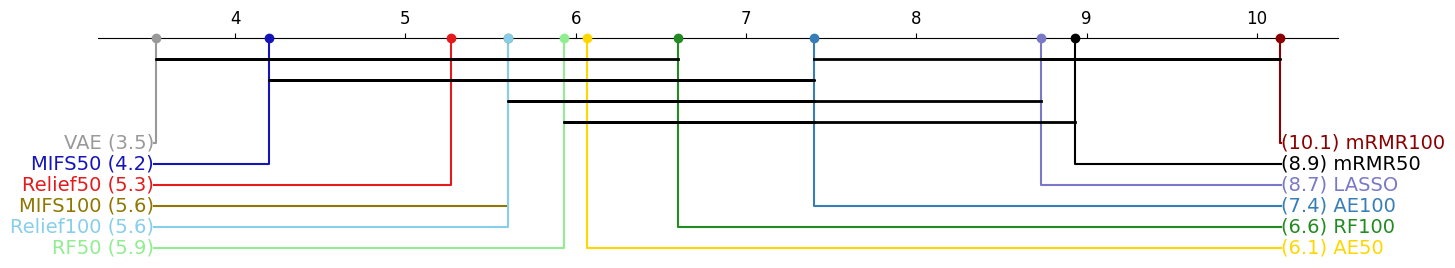

In [23]:
# Crear la figura
plt.figure(figsize=(16, 3), dpi=100)

algorithm_colors = {
    "LASSO": "#7979c7",         # Azul
    "AE50": "#FFD700",          # Naranja
    "AE100": "#377eb8",         # Gris
    "VAE": "#999999",           # Rojo
    "mRMR50": "#000000",        # Celeste claro
    "mRMR100": "#8b0000",       # Azul oscuro
    "MIFS50": "#1414b8",        # Verde claro
    "MIFS100": "#8f7700",       # Verde oscuro
    "Relief50": "#e41a1c",      # Rojo claro
    "Relief100": "#87CEEB",     # Púrpura
    "RF50": "#90EE90",      # Rojo claro
    "RF100": "#228B22",     # Púrpura
}
label_props = {"fontsize": 14}  

ax = sp.critical_difference_diagram(rankings, p_matrix, label_props=label_props, color_palette=algorithm_colors, label_fmt_right = '({rank:.1f}) {label}', label_fmt_left = '{label} ({rank:.1f})', )
plt.plot()

In [29]:
clr_classifiers = clrs.pivot(columns="Model", index=["Dataset", "FS_Method"], values="AUC")

In [33]:
statistic, p_value, ranking, rank_cmp  = stac.friedman_test(*np.transpose(np.asarray(clr_classifiers)))
ranks = {key: rank_cmp[i] for i, key in enumerate(list(clr_classifiers.columns))} 
rankings = {key: ranking[i] for i, key in enumerate(list(clr_classifiers.columns))} 
comparisons, z_values, p_values, adj_p_values = stac.finner_multitest(ranks)
adj_p_values = np.asarray(adj_p_values)
for comparison, p_value in zip(comparisons, adj_p_values):
    print(f"{comparison}: {p_value:.6f}")

Boosting vs LogisticRegression: 0.000000
KNN vs LogisticRegression: 0.000000
KNN vs RandomForest: 0.000000
KNN vs SVM: 0.000000
LogisticRegression vs RandomForest: 0.000001
Boosting vs SVM: 0.000001
Boosting vs KNN: 0.000005
LogisticRegression vs SVM: 0.000025
Boosting vs RandomForest: 0.000030
RandomForest vs SVM: 0.423711


In [31]:
classifiers = ["Boosting", "LogisticRegression", "KNN", "RandomForest", "SVM"]

# Define the p-values between classifiers (pairs as tuples)
p_values = {
    ("Boosting", "LogisticRegression"): 0.0000000000000000000000000000000000000000000000000000000001,
    ("KNN", "LogisticRegression"): 0.0000000000000000000000000000000000000000000000000000000001,
    ("KNN", "RandomForest"): 0.0000000000000000000000000000000000000000000000000000000001,
    ("KNN", "SVM"): 0.0000000000000000000000000000000000000000000000000000000001,
    ("LogisticRegression", "RandomForest"): 0.000001,
    ("Boosting", "SVM"): 0.000001,
    ("Boosting", "KNN"): 0.000005,
    ("LogisticRegression", "SVM"): 0.000025,
    ("Boosting", "RandomForest"): 0.000030,
    ("RandomForest", "SVM"): 0.423711,
    # You had this 1.1102230246251565e-16 value without a pair, ignore or clarify?
}

# Initialize empty DataFrame with NaNs
p_matrix = pd.DataFrame(np.nan, index=classifiers, columns=classifiers)

# Fill symmetric p-values
for (c1, c2), p in p_values.items():
    p_matrix.loc[c1, c2] = p
    p_matrix.loc[c2, c1] = p

# Set diagonal to 0 (p-value comparing the same classifier)
np.fill_diagonal(p_matrix.values, 0)

print(p_matrix)

                        Boosting  LogisticRegression           KNN  \
Boosting            0.000000e+00        1.000000e-58  5.000000e-06   
LogisticRegression  1.000000e-58        0.000000e+00  1.000000e-58   
KNN                 5.000000e-06        1.000000e-58  0.000000e+00   
RandomForest        3.000000e-05        1.000000e-06  1.000000e-58   
SVM                 1.000000e-06        2.500000e-05  1.000000e-58   

                    RandomForest           SVM  
Boosting            3.000000e-05  1.000000e-06  
LogisticRegression  1.000000e-06  2.500000e-05  
KNN                 1.000000e-58  1.000000e-58  
RandomForest        0.000000e+00  4.237110e-01  
SVM                 4.237110e-01  0.000000e+00  


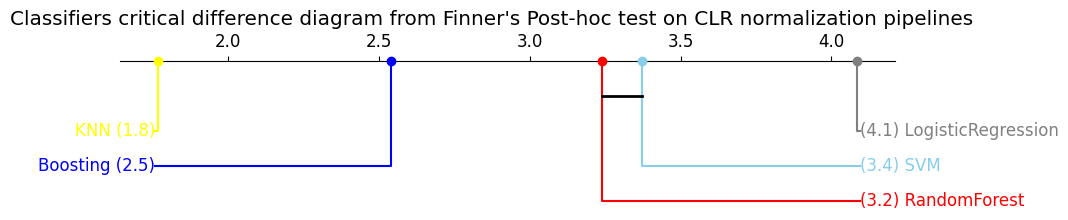

In [32]:
plt.figure(figsize=(10, 2), dpi=100)

plt.suptitle('Classifiers critical difference diagram from Finner\'s Post-hoc test on CLR normalization pipelines ', y=1.1)

ax = sp.critical_difference_diagram(rankings, p_matrix, color_palette=colors)
plt.plot()

In [51]:
rafs = pd.read_csv("NestedRAFeatureSelectionFINAL.csv", index_col=0)
clrfs = pd.read_csv("NestedCLRFeatureSelectionFINAL.csv", index_col=0)
logtssfs = pd.read_csv("NestedlogTSSFeatureSelectionFINAL.csv", index_col=0)
pafs = pd.read_csv("NestedPAFeatureSelectionFINAL.csv", index_col=0)

rafs["Normalization"] = "RA"
clrfs["Normalization"] = "CLR"
logtssfs["Normalization"] = "logRA"
pafs["Normalization"] = "PA"

clrfs["FS_Method"] = clrfs["FS_Method"].str.replace("mRMR", "MRMR", regex=False)

In [49]:
pafs.FS_Method.unique()

array(['VAE', 'RF100', 'RF50', 'Relief100', 'Relief50', 'MRMR100',
       'MRMR50', 'MIFS100', 'MIFS50', 'LASSO', 'AE100', 'AE50'],
      dtype=object)

In [52]:
full = pd.concat((rafs, clrfs, logtssfs, pafs)).pivot(index=['Dataset', "Model", "Normalization"], columns=['FS_Method'], values='AUC')

In [53]:
statistic, p_value, ranking, rank_cmp  = stac.friedman_test(*np.transpose(np.asarray(full)))
ranks = {key: rank_cmp[i] for i, key in enumerate(list(full.columns))} 
rankings = {key: ranking[i] for i, key in enumerate(list(full.columns))} 

comparisons, z_values, p_values, adj_p_values = stac.finner_multitest(ranks)
adj_p_values = np.asarray(adj_p_values)
for comparison, p_value in zip(comparisons, adj_p_values):
    print(f"{comparison}: {p_value:.6f}")

AE100 vs LASSO: 0.000000
AE100 vs MRMR100: 0.000000
AE100 vs MRMR50: 0.000000
AE100 vs RF100: 0.000000
AE100 vs VAE: 0.000000
AE50 vs LASSO: 0.000000
AE50 vs MRMR100: 0.000000
AE50 vs MRMR50: 0.000000
AE50 vs RF100: 0.000000
AE50 vs VAE: 0.000000
LASSO vs MIFS100: 0.000000
LASSO vs MIFS50: 0.000000
LASSO vs VAE: 0.000000
MIFS100 vs MRMR100: 0.000000
MIFS100 vs MRMR50: 0.000000
MIFS100 vs RF100: 0.000000
MIFS100 vs VAE: 0.000000
MIFS50 vs MRMR100: 0.000000
MIFS50 vs MRMR50: 0.000000
MIFS50 vs RF100: 0.000000
MIFS50 vs RF50: 0.000000
MIFS50 vs Relief100: 0.000000
MIFS50 vs Relief50: 0.000000
MRMR100 vs Relief50: 0.000000
MRMR100 vs VAE: 0.000000
MRMR50 vs VAE: 0.000000
RF100 vs VAE: 0.000000
RF50 vs VAE: 0.000000
Relief100 vs VAE: 0.000000
Relief50 vs VAE: 0.000000
MRMR100 vs Relief100: 0.000000
MIFS100 vs RF50: 0.000000
AE100 vs RF50: 0.000000
MRMR50 vs Relief50: 0.000000
LASSO vs Relief50: 0.000000
AE50 vs RF50: 0.000000
MIFS50 vs VAE: 0.000000
MRMR100 vs RF50: 0.000000
MRMR50 vs Relie

In [55]:
methods = [
    "LASSO", "MIFS50", "VAE", "MRMR100", "MRMR50", "RF100", "RF50",
    "AE50", "AE100", "MIFS100", "Relief50", "Relief100"
]

# Nuevos p-valores proporcionados
p_values = {
    ("AE100", "LASSO"): 0.0000001,
    ("AE100", "MRMR100"): 0.0000001,
    ("AE100", "MRMR50"): 0.0000001,
    ("AE100", "RF100"): 0.0000001,
    ("AE100", "VAE"): 0.0000001,
    ("AE50", "LASSO"): 0.0000001,
    ("AE50", "MRMR100"): 0.0000001,
    ("AE50", "MRMR50"): 0.000001,
    ("AE50", "RF100"): 0.0000001,
    ("AE50", "VAE"): 0.0000001,
    ("LASSO", "MIFS100"): 0.0000001,
    ("LASSO", "MIFS50"): 0.0000001,
    ("LASSO", "VAE"): 0.0000001,
    ("MIFS100", "MRMR100"): 0.0000001,
    ("MIFS100", "MRMR50"): 0.0000001,
    ("MIFS100", "RF100"): 0.0000001,
    ("MIFS100", "VAE"): 0.0000001,
    ("MIFS50", "MRMR100"): 0.0000001,
    ("MIFS50", "MRMR50"): 0.0000001,
    ("MIFS50", "RF100"): 0.0000001,
    ("MIFS50", "RF50"): 0.0000001,
    ("MIFS50", "Relief100"): 0.0000001,
    ("MIFS50", "Relief50"): 0.0000001,
    ("MRMR100", "Relief50"): 0.0000001,
    ("MRMR100", "VAE"): 0.0000001,
    ("MRMR50", "VAE"): 0.0000001,
    ("RF100", "VAE"): 0.0000001,
    ("RF50", "VAE"): 0.0000001,
    ("Relief100", "VAE"): 0.0000001,
    ("Relief50", "VAE"): 0.0000001,
    ("MRMR100", "Relief100"): 0.0000001,
    ("MIFS100", "RF50"): 0.0000001,
    ("AE100", "RF50"): 0.0000001,
    ("MRMR50", "Relief50"): 0.0000001,
    ("LASSO", "Relief50"): 0.0000001,
    ("AE50", "RF50"): 0.0000001,
    ("MIFS50", "VAE"): 0.0000001,
    ("MRMR100", "RF50"): 0.0000001,
    ("MRMR50", "Relief100"): 0.0000001,
    ("LASSO", "Relief100"): 0.0000001,
    ("RF100", "Relief50"): 0.0000001,
    ("AE50", "MIFS50"): 0.0000001,
    ("MIFS100", "Relief100"): 0.0000001,
    ("RF100", "Relief100"): 0.000001,
    ("AE100", "MIFS50"): 0.000003,
    ("MIFS100", "Relief50"): 0.000005,
    ("AE100", "Relief100"): 0.000043,
    ("MIFS100", "MIFS50"): 0.000307,
    ("AE50", "Relief100"): 0.000392,
    ("AE100", "Relief50"): 0.000401,
    ("MRMR50", "RF50"): 0.002129,
    ("LASSO", "RF50"): 0.002435,
    ("MRMR100", "RF100"): 0.002579,
    ("AE50", "Relief50"): 0.002629,
    ("RF50", "Relief50"): 0.003233,
    ("RF100", "RF50"): 0.013623,
    ("LASSO", "MRMR100"): 0.014272,
    ("MRMR100", "MRMR50"): 0.015925,
    ("RF50", "Relief100"): 0.016158,
    ("AE50", "MIFS100"): 0.123490,
    ("AE100", "MIFS100"): 0.317597,
    ("MRMR50", "RF100"): 0.555840,
    ("LASSO", "RF100"): 0.580524,
    ("Relief100", "Relief50"): 0.590250,
    ("AE100", "AE50"): 0.592371,
    ("LASSO", "MRMR50"): 0.963875,
}

# Crear matriz vacía
p_matrix = pd.DataFrame(np.nan, index=methods, columns=methods)

# Rellenar la matriz con valores simétricos
for (m1, m2), p in p_values.items():
    p_matrix.loc[m1, m2] = p
    p_matrix.loc[m2, m1] = p

# Diagonal en cero
np.fill_diagonal(p_matrix.values, 0)

# Mostrar matriz
print(p_matrix)


                  LASSO        MIFS50           VAE       MRMR100  \
LASSO      0.000000e+00  1.000000e-07  1.000000e-07  1.427200e-02   
MIFS50     1.000000e-07  0.000000e+00  1.000000e-07  1.000000e-07   
VAE        1.000000e-07  1.000000e-07  0.000000e+00  1.000000e-07   
MRMR100    1.427200e-02  1.000000e-07  1.000000e-07  0.000000e+00   
MRMR50     9.638750e-01  1.000000e-07  1.000000e-07  1.592500e-02   
RF100      5.805240e-01  1.000000e-07  1.000000e-07  2.579000e-03   
RF50       2.435000e-03  1.000000e-07  1.000000e-07  1.000000e-07   
AE50       1.000000e-07  1.000000e-07  1.000000e-07  1.000000e-07   
AE100      1.000000e-07  3.000000e-06  1.000000e-07  1.000000e-07   
MIFS100    1.000000e-07  3.070000e-04  1.000000e-07  1.000000e-07   
Relief50   1.000000e-07  1.000000e-07  1.000000e-07  1.000000e-07   
Relief100  1.000000e-07  1.000000e-07  1.000000e-07  1.000000e-07   

                 MRMR50         RF100          RF50          AE50  \
LASSO      9.638750e-01  5.805240

[]

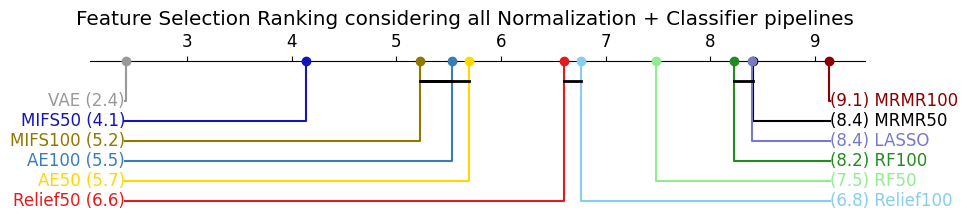

In [57]:
plt.figure(figsize=(10, 2), dpi=100)
algorithm_colors = {
    "LASSO": "#7979c7",         # Azul
    "AE50": "#FFD700",          # Naranja
    "AE100": "#377eb8",         # Gris
    "VAE": "#999999",           # Rojo
    "MRMR50": "#000000",        # Celeste claro
    "MRMR100": "#8b0000",       # Azul oscuro
    "MIFS50": "#1414b8",        # Verde claro
    "MIFS100": "#8f7700",       # Verde oscuro
    "Relief50": "#e41a1c",      # Rojo claro
    "Relief100": "#87CEEB",     # Púrpura
    "RF50": "#90EE90",      # Rojo claro
    "RF100": "#228B22",     # Púrpura
}
plt.suptitle('Feature Selection Ranking considering all Normalization + Classifier pipelines', y=1.1)

ax = sp.critical_difference_diagram(rankings, p_matrix, color_palette=algorithm_colors)

plt.plot()